## Cálculo de los días tipo

### K-Means clustering

#### Load the data

In [1]:
import pandas as pd

data_types = {'origen': 'string',
			  'destino': 'string', 
			  'distancia': 'string',
			  'weekday_flag': 'int64',
			  'viajes': 'float',
			  'viajes_km': 'float'
}

criteria = list(data_types.keys())
parse_dates = ['date_str']

data = pd.read_csv('D:/Documents/Proyectos/MITMA/Data/3-Results/Leon_MITMA_2023.csv', dtype=data_types, parse_dates=parse_dates)
data = data[criteria + parse_dates]
data['date_str'] = pd.to_datetime(data['date_str'])

print(data.info())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22689026 entries, 0 to 22689025
Data columns (total 7 columns):
 #   Column        Dtype         
---  ------        -----         
 0   origen        string        
 1   destino       string        
 2   distancia     string        
 3   weekday_flag  int64         
 4   viajes        float64       
 5   viajes_km     float64       
 6   date_str      datetime64[ns]
dtypes: datetime64[ns](1), float64(2), int64(1), string(3)
memory usage: 1.2 GB
None


#### Calculate the optimal number of clusters

101211
49538


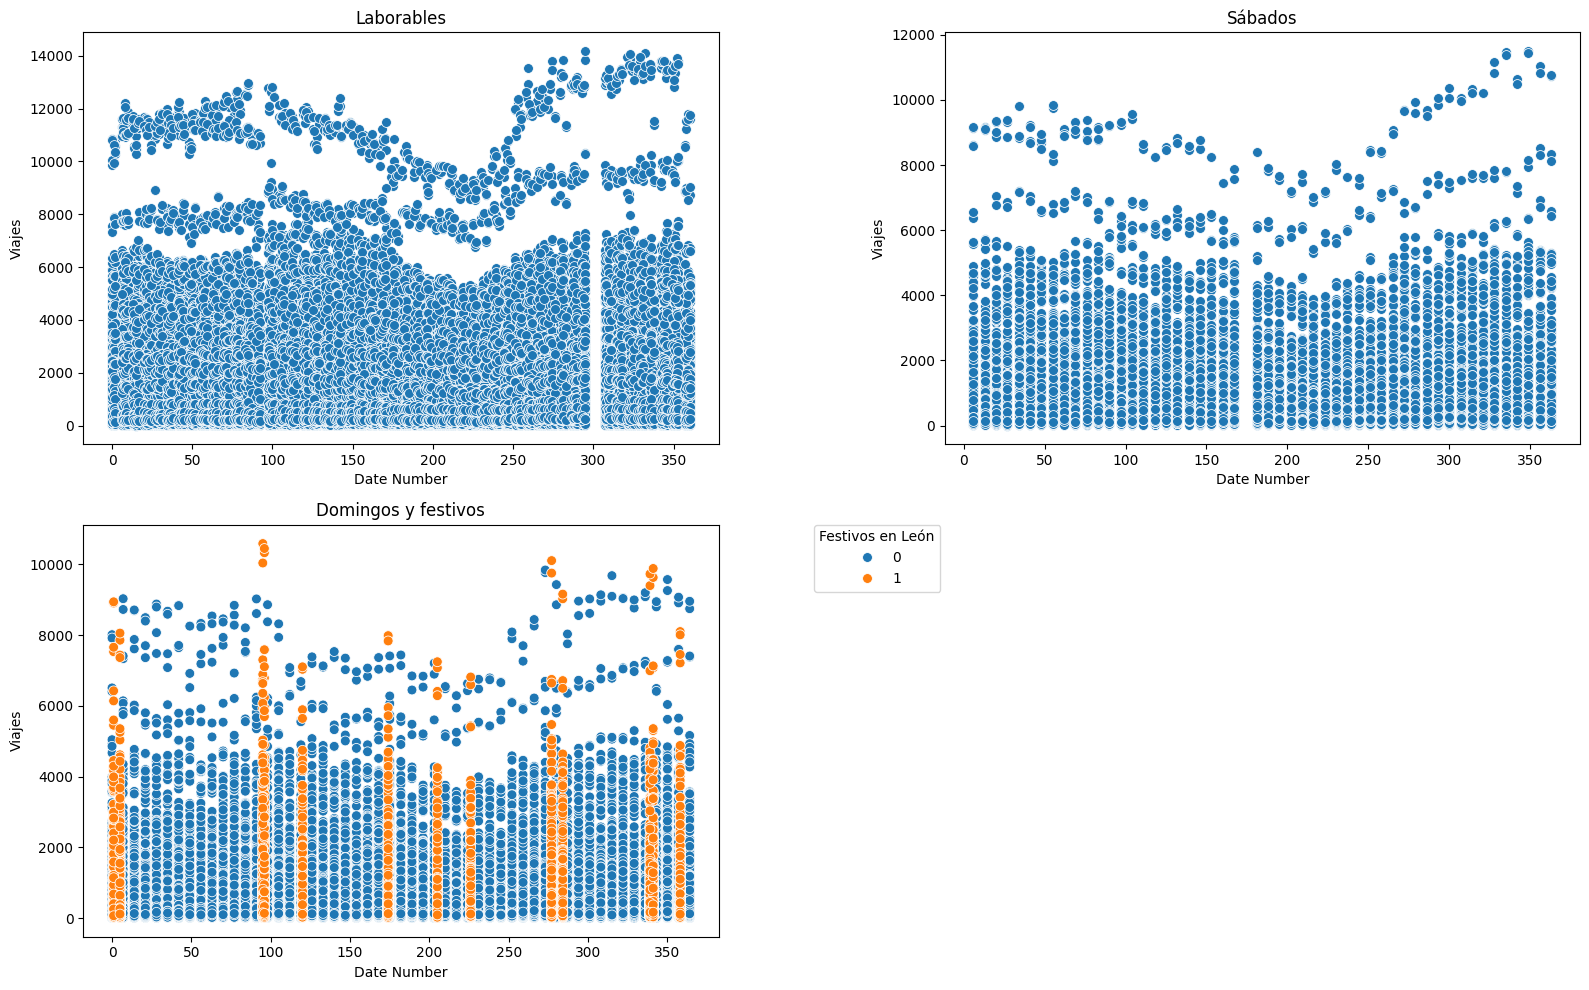

In [2]:
import seaborn as sns
import matplotlib.pyplot as plt
from datetime import datetime

# Step 0 data pre-processing
# Create a concatenate column
data['OD_pair'] = data['origen'] + '-' + data['destino']

# Perform a groupby to collapse the data after ignoring socioeconomic features: income, gender, age
data = data.groupby(['origen', 'destino', 'OD_pair', 'weekday_flag', 'date_str']).agg(
	viajes=('viajes', 'sum'),
	viajes_km=('viajes_km', 'sum')
).reset_index()

# Exclude national bank holidays

bank_holidays = pd.to_datetime([ 
	'02 January 2023',
	'06 January 2023',
	'06 April 2023',
	'07 April 2023',
	'01 May 2023',
	'24 June 2023',
	'25 July 2023',
	'15 August 2023',
	'05 October 2023',
	'12 October 2023',
	'01 November 2023',
	'06 December 2023',
	'08 December 2023',
	'25 December 2023'
])

data['bh_flag'] = data['date_str'].isin(bank_holidays).astype(int)

# Exclude the diagonal
data = data.loc[data['origen'] != data['destino']]
# print(f"After collapsing the data and excluding the diagonal, the number of rows is: {len(data)}")

# Areas in scope 
in_scope = ['24065', '24163', '24189', '2408901', '2408902', '2408903', '2408904', '2408905', 
			'2408906', '2408907', '2408908', '2408909', '2408910', '2414201', '2414202', '2414203',
			'2422201', '2422202', '24061_AM', '24162_AM', '24175_AM']


data_weekday = data[data['weekday_flag'] == 1]
data_weekday = data_weekday[data_weekday['bh_flag'] == 0]
data_weekday = data_weekday[data_weekday['origen'].isin(in_scope)]
data_weekday = data_weekday[data_weekday['destino'].isin(in_scope)]

data_weekend = data[data['weekday_flag'] == 0]
data_bh = data[data['bh_flag'] == 1]
data_non_working = pd.concat([data_weekend, data_bh])
data_non_working = data_non_working[data_non_working['origen'].isin(in_scope)]
data_non_working = data_non_working[data_non_working['destino'].isin(in_scope)]


# Exclude small relationships: less than 4000 trips per day => 4,000*365 = 1,460,000 trips per year
threshold = 1  # Parameterized threshold
od_pair_totals = data_weekday.groupby('OD_pair')['viajes'].sum().reset_index()
filtered_od_pairs = od_pair_totals[od_pair_totals['viajes'] >= threshold]
data_weekday = data_weekday[data_weekday['OD_pair'].isin(filtered_od_pairs['OD_pair'])]
print(len(data_weekday))


# Exclude small relationships: less than 3,000 trips per day => 2,884 * 52 * 2 ~ 300,000 trips per year
threshold = 1
od_pair_totals = data_non_working.groupby('OD_pair')['viajes'].sum().reset_index()
filtered_od_pairs = od_pair_totals[od_pair_totals['viajes'] >= threshold]
data_non_working = data_non_working[data_non_working['OD_pair'].isin(filtered_od_pairs['OD_pair'])]
print(len(data_non_working))

# print(f"After removing OD pairs with less than {threshold} trips per year, the number of rows is: {len(data_weekday)}")
# print(data_weekday.head())

# 2. Convert 'date_str' to numerical representation (e.g., days since min date)
data_weekday['date_num'] = (data_weekday['date_str'] - data_weekday['date_str'].min()).dt.days
data_non_working['date_num'] = (data_non_working['date_str'] - data_non_working['date_str'].min()).dt.days

# Fill NaN values with 0
data_weekday = data_weekday.fillna(0)
data_non_working = data_non_working.fillna(0)

data_saturdays = data_non_working[(data_non_working['date_str'].dt.weekday == 5) & (data_non_working['bh_flag'] == 0)]
data_sundays = data_non_working[(data_non_working['date_str'].dt.weekday == 6) | (data_non_working['bh_flag'] == 1)]

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Plot for weekday data on the first subplot
sns.scatterplot(x=data_weekday['date_num'], y=data_weekday['viajes'], s=50, ax=axes[0, 0])
axes[0, 0].set_title("Laborables")
axes[0, 0].set_xlabel("Date Number")
axes[0, 0].set_ylabel("Viajes")

# Plot for Saturday data on the second subplot
sns.scatterplot(x=data_saturdays['date_num'], y=data_saturdays['viajes'], s=50, ax=axes[0, 1])
axes[0, 1].set_title("Sábados")
axes[0, 1].set_xlabel("Date Number")
axes[0, 1].set_ylabel("Viajes")

# Plot for Sunday data on the third subplot
sns.scatterplot(x=data_sundays['date_num'], y=data_sundays['viajes'], hue=data_sundays['bh_flag'], s=50, ax=axes[1, 0])
axes[1, 0].set_title("Domingos y festivos")
axes[1, 0].set_xlabel("Date Number")
axes[1, 0].set_ylabel("Viajes")

# Remove the fourth subplot if not needed
axes[1, 1].axis('off')  # Hides the empty subplot

# Positioning the legend outside the main plot area
legend = axes[1, 0].legend(title='Festivos en León', bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0)
legend.set_bbox_to_anchor((1.15, 1))  # Further adjust this to move it farther if needed


plt.tight_layout()
plt.show()

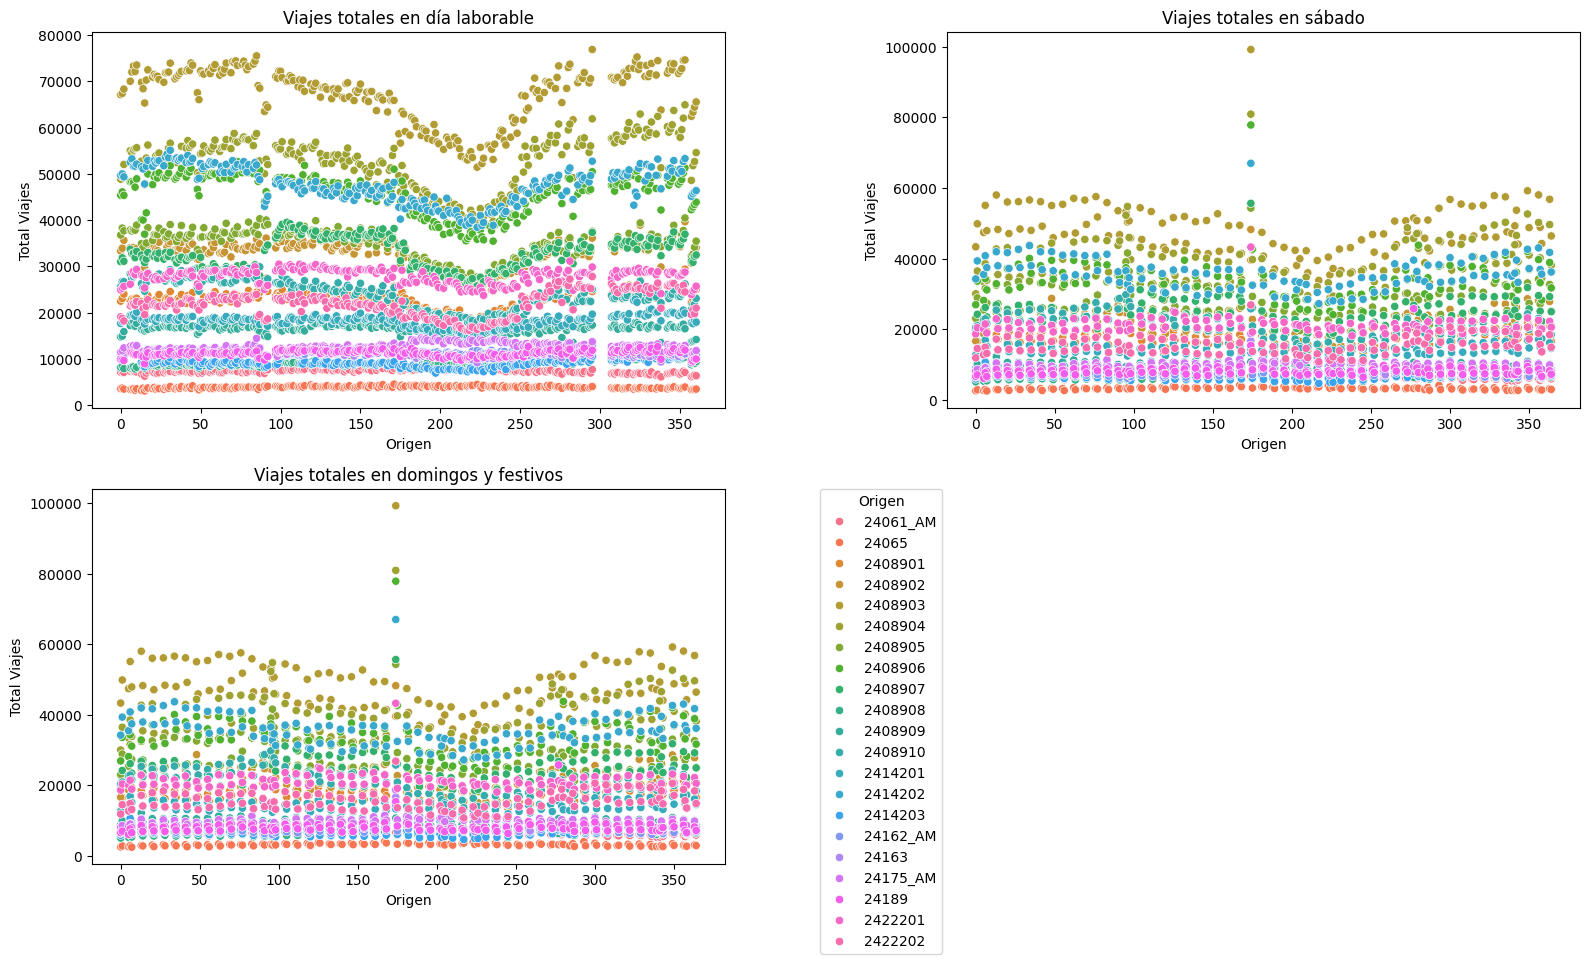

In [3]:
data_grouped_weekday = data_weekday.groupby(['origen','date_num']).agg(
    total_viajes=('viajes', 'sum'),
    total_viajes_km=('viajes_km', 'sum')
).reset_index()

data_grouped_weekend = data_non_working.groupby(['origen','date_num']).agg(
    total_viajes=('viajes', 'sum'),
    total_viajes_km=('viajes_km', 'sum')
).reset_index()

# Plotting the aggregated data
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Plot for weekday data
sns.scatterplot(x=data_grouped_weekday['date_num'], y=data_grouped_weekday['total_viajes'], hue = data_grouped_weekday['origen'], ax=axes[0, 0], legend= None)
axes[0, 0].set_title("Viajes totales en día laborable")
axes[0, 0].set_xlabel("Origen")
axes[0, 0].set_ylabel("Total Viajes")

# Plot for Saturday data
sns.scatterplot(x=data_grouped_weekend['date_num'], y=data_grouped_weekend['total_viajes'], hue = data_grouped_weekend['origen'],ax=axes[0, 1], legend= None)
axes[0, 1].set_title("Viajes totales en sábado")
axes[0, 1].set_xlabel("Origen")
axes[0, 1].set_ylabel("Total Viajes")

# Plot for Saturday data
sns.scatterplot(x=data_grouped_weekend['date_num'], y=data_grouped_weekend['total_viajes'], hue = data_grouped_weekend['origen'],ax=axes[1, 0])
axes[1, 0].set_title("Viajes totales en domingos y festivos")
axes[1, 0].set_xlabel("Origen")
axes[1, 0].set_ylabel("Total Viajes")

# Move the legend outside the weekend plot
axes[1, 1].axis('off')  # Hides the empty subplot

# Positioning the legend outside the main plot area
legend = axes[1, 0].legend(title='Origen', bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0)
legend.set_bbox_to_anchor((1.15, 1))  # Further adjust this to move it farther if needed

plt.tight_layout()
plt.show()
